In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [4]:
df = pd.read_csv('athlete_events_limpo.csv')
df = df[df['NOC'] != 'URS']

dfM = df[df['Sex'] == 'F'].copy()
dfH = df[df['Sex'] == 'M'].copy()

assert dfM['Sex'].eq('F').all()
assert dfH['Sex'].eq('M').all()

dfM.to_csv('athlete_events_mulheres.csv', index=False)
dfH.to_csv('athlete_events_homens.csv', index=False)

dfM.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,NaN
4,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,NaN
6,21,Ragnhild Margrethe Aamodt,F,27.0,163.0,NaN,Norway,NOR,2008 Summer,2008,Summer,Beijing,Handball,Handball Women's Handball,Gold
7,22,Andreea Aanei,F,22.0,170.0,125.0,Romania,ROU,2016 Summer,2016,Summer,Rio de Janeiro,Weightlifting,Weightlifting Women's Super-Heavyweight,NaN
13,29,Willemien Aardenburg,F,22.0,NaN,NaN,Netherlands,NED,1988 Summer,1988,Summer,Seoul,Hockey,Hockey Women's Hockey,Bronze


Text(0.5, 9.444444444444438, 'Ano')

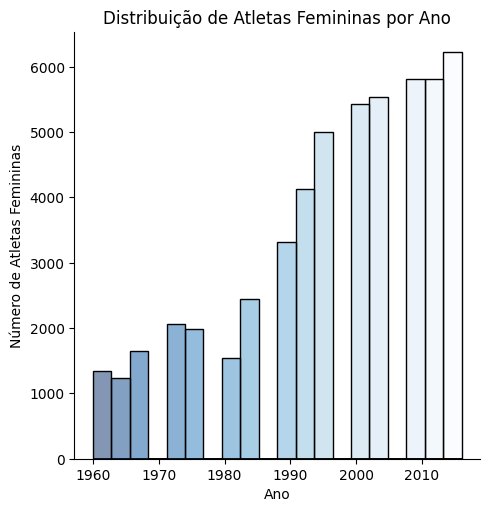

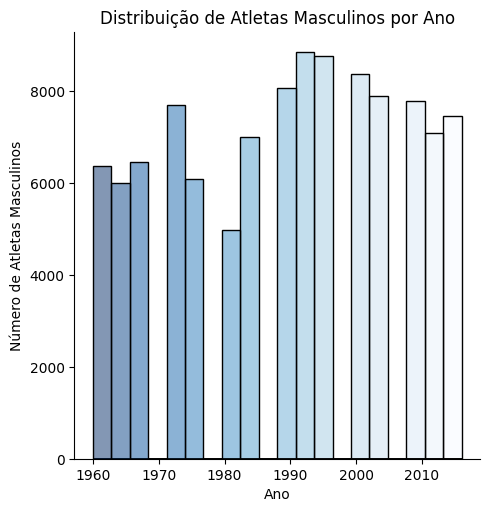

In [ ]:
sns.displot(dfM, x='Year', bins=20, hue='Year', palette='Blues_r', legend=False)
plt.title('Distribuição de Atletas Femininas por Ano')
plt.ylabel('Número de Atletas Femininas')
plt.xlabel('Ano')
sns.displot(dfH, x='Year', bins=20, hue='Year', palette='Blues_r', legend=False)
plt.title('Distribuição de Atletas Masculinos por Ano')
plt.ylabel('Número de Atletas Masculinos')
plt.xlabel('Ano')

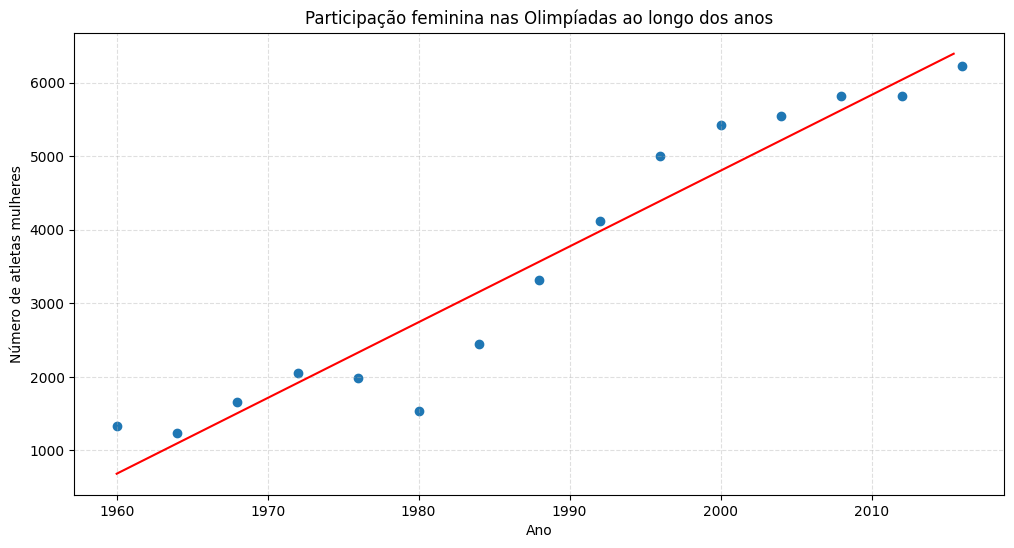

In [6]:
def gen_line(x_min, x_max, n_points, a, b):
    interval = x_max - x_min
    interval_value = interval / n_points
    
    x_result = []
    y_result = []

    for i in range(n_points):
        current_x = x_min + i * interval_value
        x_result.append(current_x)
        y_result.append(a * current_x + b)
        
    return x_result, y_result


def show_regression(x, y, a, b):
    N = 100

    plt.scatter(x, y)

    line_1 = gen_line(min(x), max(x), N, a, b)
    plt.plot(line_1[0], line_1[1], c="red")

    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()


mulheres_por_ano = dfM.groupby('Year').size().reset_index(name='Qtd_Mulheres')

x = mulheres_por_ano['Year'].tolist()
y = mulheres_por_ano['Qtd_Mulheres'].tolist()

media_x = sum(x) / len(x)
media_y = sum(y) / len(y)

numerador = sum((xi - media_x) * (yi - media_y) for xi, yi in zip(x, y))
denominador = sum((xi - media_x) ** 2 for xi in x)

a = numerador / denominador
b = media_y - a * media_x

plt.figure(figsize=(12, 6))
plt.title('Participação feminina nas Olimpíadas ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('Número de atletas mulheres')

show_regression(x, y, a, b)

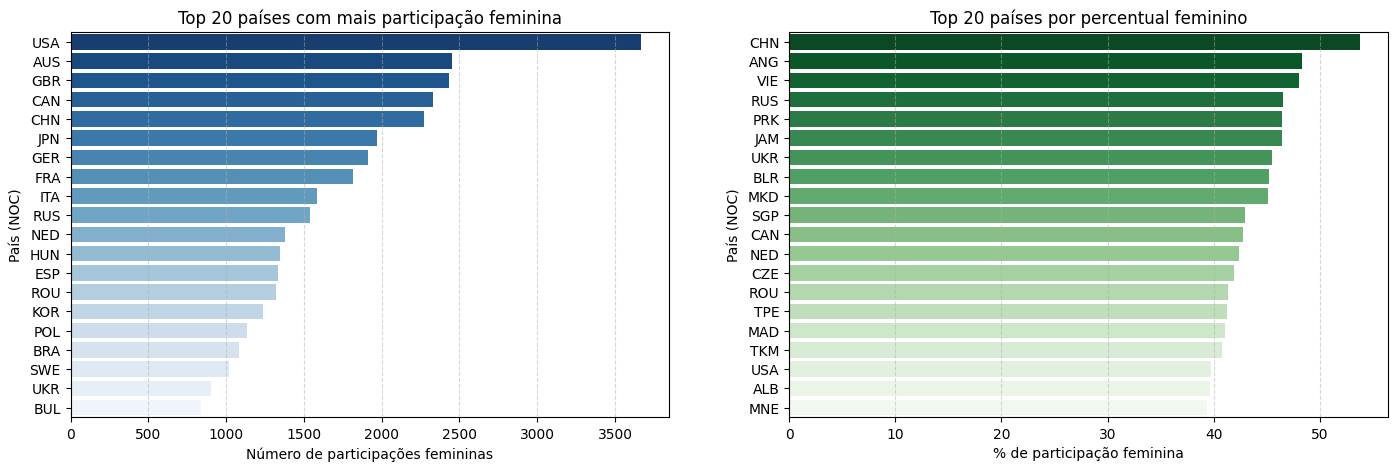

In [21]:
resumo_paises = pd.DataFrame({'Total_Participacoes': df.groupby('NOC').size(),'Participacoes_Femininas': dfM.groupby('NOC').size()}).fillna(0)

resumo_paises['Percentual_Feminino'] = (100 * resumo_paises['Participacoes_Femininas'] / resumo_paises['Total_Participacoes'])

top_absoluto = (resumo_paises.sort_values('Participacoes_Femininas', ascending=False).head(20).reset_index())

top_percentual = (resumo_paises[resumo_paises['Total_Participacoes'] >= 50].sort_values('Percentual_Feminino', ascending=False).head(20).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

sns.barplot(data=top_absoluto,y='NOC',x='Participacoes_Femininas',hue='NOC',palette='Blues_r',legend=False,ax=axes[0])
axes[0].set_title('Top 20 países com mais participação feminina')
axes[0].set_xlabel('Número de participações femininas')
axes[0].set_ylabel('País (NOC)')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

sns.barplot(data=top_percentual,y='NOC',x='Percentual_Feminino',hue='NOC',palette='Greens_r',legend=False,ax=axes[1])
axes[1].set_title('Top 20 países por percentual feminino')
axes[1].set_xlabel('% de participação feminina')
axes[1].set_ylabel('País (NOC)')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

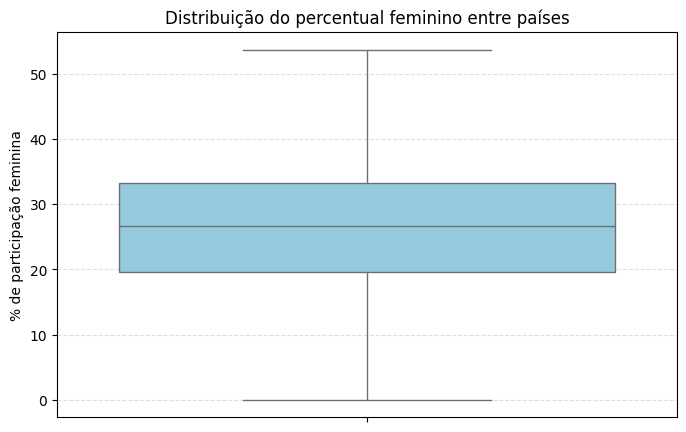

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=resumo_paises[resumo_paises['Total_Participacoes'] >= 50]['Percentual_Feminino'], color='skyblue')
plt.title('Distribuição do percentual feminino entre países')
plt.ylabel('% de participação feminina')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

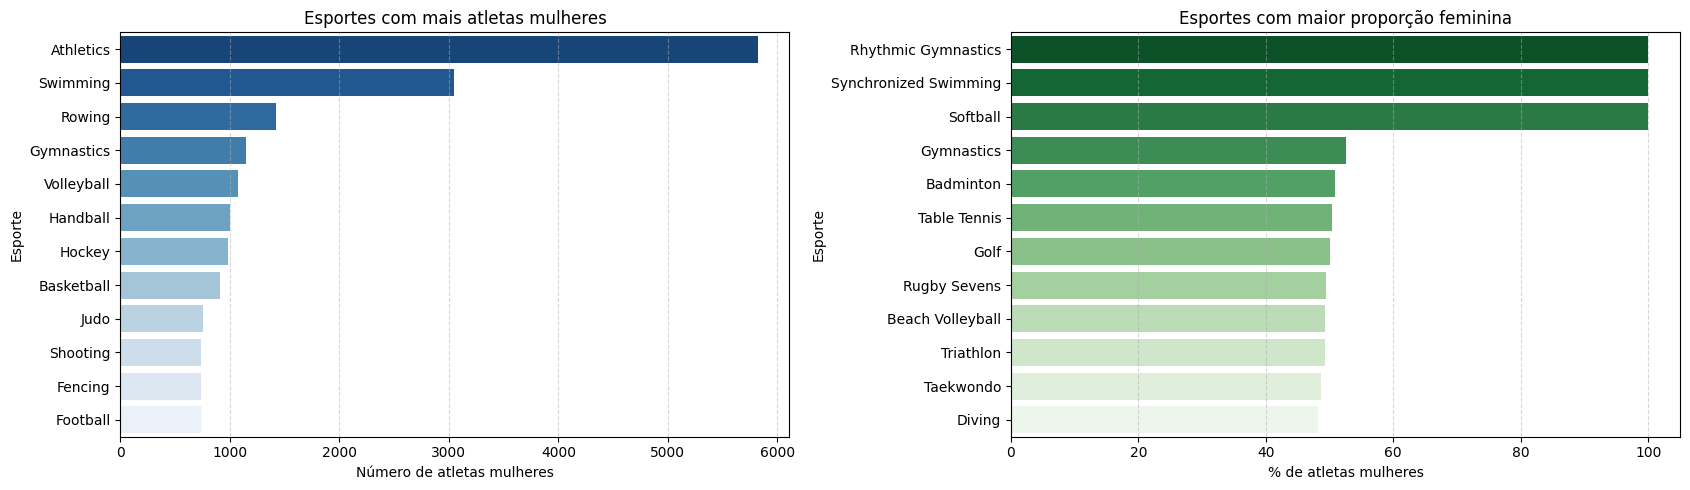

In [9]:
df_esportes = df.drop_duplicates(subset=['ID', 'Year', 'Sport']).copy()

resumo_esportes = pd.DataFrame({'Total_Atletas': df_esportes.groupby('Sport')['ID'].nunique(),'Atletas_Femininas': df_esportes[df_esportes['Sex'] == 'F'].groupby('Sport')['ID'].nunique()}).fillna(0)

resumo_esportes['Atletas_Femininas'] = resumo_esportes['Atletas_Femininas'].astype(int)
resumo_esportes['Percentual_Feminino'] = (100 * resumo_esportes['Atletas_Femininas'] / resumo_esportes['Total_Atletas'])

top_abs_esportes = (resumo_esportes.sort_values('Atletas_Femininas', ascending=False).head(12).reset_index())

top_pct_esportes = (resumo_esportes[resumo_esportes['Total_Atletas'] >= 100].sort_values('Percentual_Feminino', ascending=False).head(12).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

sns.barplot(data=top_abs_esportes,y='Sport',x='Atletas_Femininas',hue='Sport',palette='Blues_r',legend=False,ax=axes[0])
axes[0].set_title('Esportes com mais atletas mulheres')
axes[0].set_xlabel('Número de atletas mulheres')
axes[0].set_ylabel('Esporte')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)


sns.barplot(data=top_pct_esportes,y='Sport',x='Percentual_Feminino',hue='Sport',palette='Greens_r',legend=False,ax=axes[1])
axes[1].set_title('Esportes com maior proporção feminina')
axes[1].set_xlabel('% de atletas mulheres')
axes[1].set_ylabel('Esporte')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

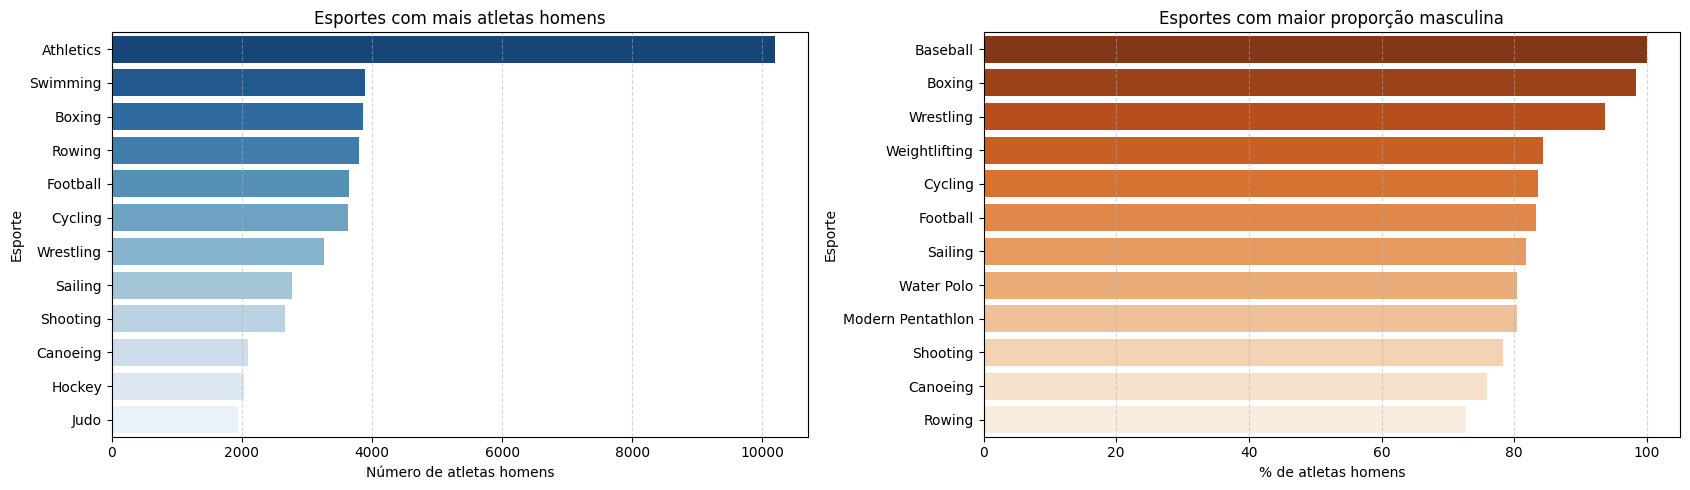

In [ ]:
resumo_esportes['Atletas_Masculinos'] = (df_esportes[df_esportes['Sex'] == 'M'].groupby('Sport')['ID'].nunique()).fillna(0).astype(int)

resumo_esportes['Percentual_Masculino'] = (100 * resumo_esportes['Atletas_Masculinos'] / resumo_esportes['Total_Atletas'])

top_abs_esportes_m = (resumo_esportes.sort_values('Atletas_Masculinos', ascending=False).head(12).reset_index())

top_pct_esportes_m = (resumo_esportes[resumo_esportes['Total_Atletas'] >= 100].sort_values('Percentual_Masculino', ascending=False).head(12).reset_index())

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

sns.barplot(data=top_abs_esportes_m, y='Sport', x='Atletas_Masculinos', hue='Sport', palette='Blues_r', legend=False, ax=axes[0])
axes[0].set_title('Esportes com mais atletas homens')
axes[0].set_xlabel('Número de atletas homens')
axes[0].set_ylabel('Esporte')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

sns.barplot(data=top_pct_esportes_m, y='Sport', x='Percentual_Masculino', hue='Sport', palette='Oranges_r', legend=False, ax=axes[1])
axes[1].set_title('Esportes com maior proporção masculina')
axes[1].set_xlabel('% de atletas homens')
axes[1].set_ylabel('Esporte')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

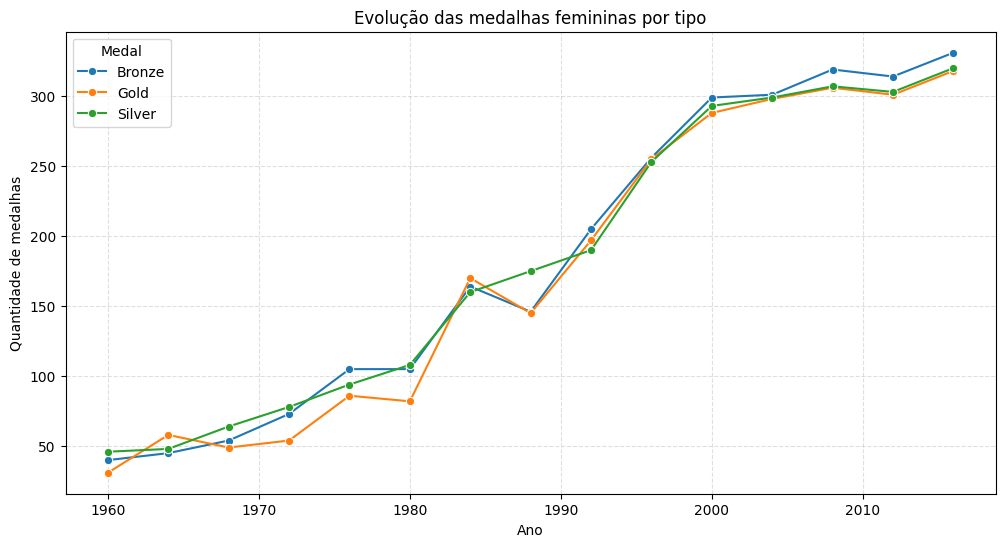

In [ ]:
medalhas_femininas = dfM[dfM['Medal'].notna()].copy()

medalhas_por_ano = (medalhas_femininas.groupby(['Year', 'Medal']).size().reset_index(name='Quantidade'))

plt.figure(figsize=(12,6))
sns.lineplot(data=medalhas_por_ano, x='Year', y='Quantidade', hue='Medal', marker='o')
plt.title('Evolução das medalhas femininas por tipo')
plt.xlabel('Ano')
plt.ylabel('Quantidade de medalhas')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

      Grupo  Participacoes  Medalhas  Medalhas_por_100_participacoes
0  Mulheres          53528      8133                           15.19
1    Homens         108979     13635                           12.51


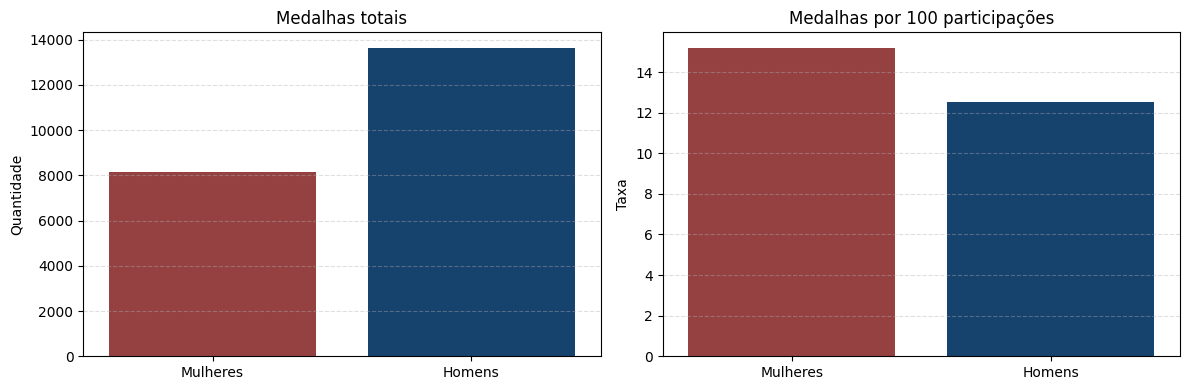

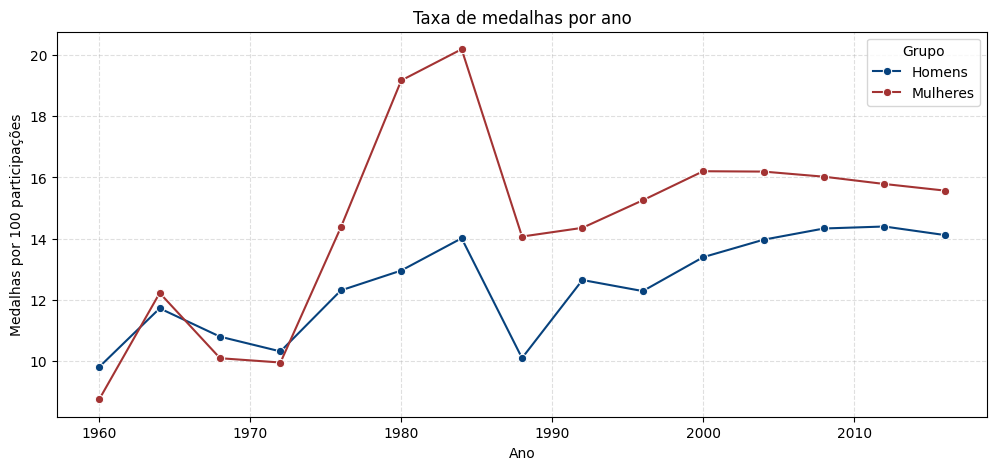

In [ ]:
bases = {'Mulheres': dfM,'Homens': dfH}

cores = {'Mulheres': "#a33333",'Homens': '#07427d'}

comparativo = (pd.DataFrame({'Grupo': list(bases.keys()),'Participacoes': [len(base) for base in bases.values()],'Medalhas': [base['Medal'].notna().sum() for base in bases.values()]}).assign(Medalhas_por_100_participacoes=lambda x: 100 * x['Medalhas'] / x['Participacoes']))

print(comparativo.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metricas = [('Medalhas', 'Medalhas totais', 'Quantidade'),('Medalhas_por_100_participacoes', 'Medalhas por 100 participações', 'Taxa')]

for ax, (coluna, titulo, eixo_y) in zip(axes, metricas):
    sns.barplot(data=comparativo,x='Grupo',y=coluna,hue='Grupo',palette=cores,legend=False,ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel('')
    ax.set_ylabel(eixo_y)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

comparativo_ano = (pd.concat(bases, names=['Grupo']).reset_index(level=0).groupby(['Grupo', 'Year']).agg(Participacoes=('Year', 'size'),Medalhas=('Medal', lambda s: s.notna().sum())).assign(Taxa_medalhas=lambda x: 100 * x['Medalhas'] / x['Participacoes']).reset_index())

plt.figure(figsize=(12, 5))
sns.lineplot(data=comparativo_ano,x='Year',y='Taxa_medalhas',hue='Grupo',marker='o',palette=cores)
plt.title('Taxa de medalhas por ano')
plt.xlabel('Ano')
plt.ylabel('Medalhas por 100 participações')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

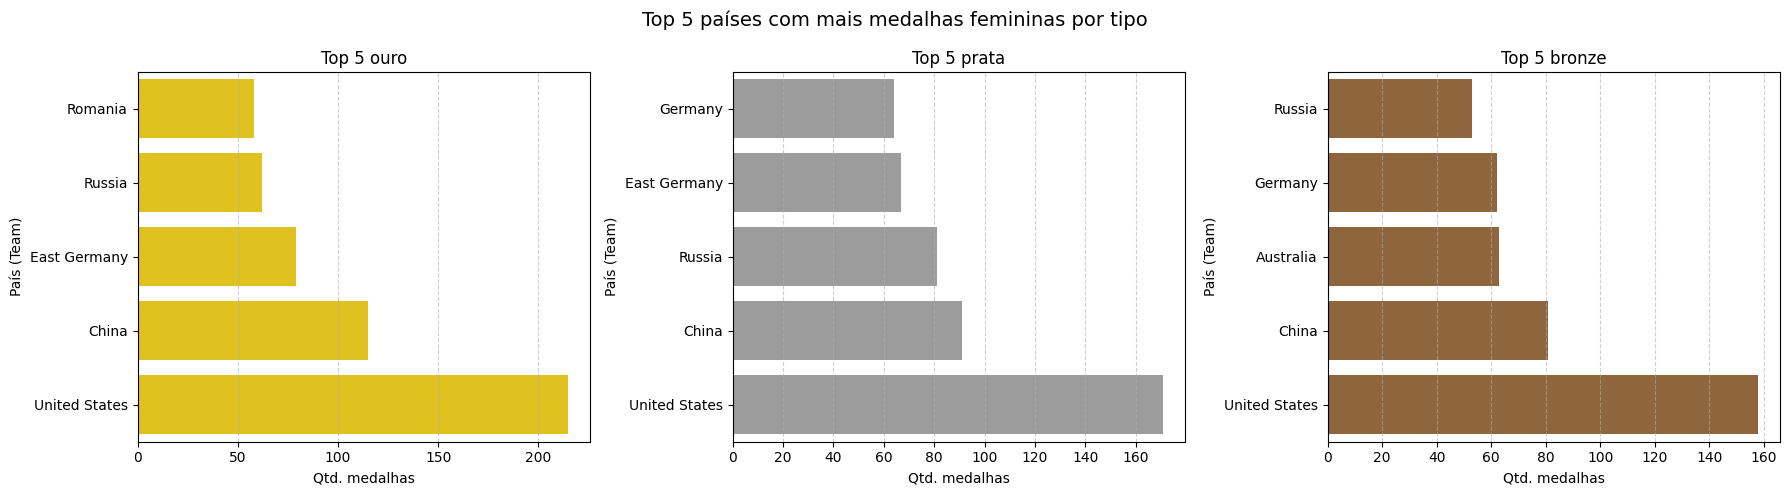

In [ ]:
medalhas_pais_fem = (dfM[dfM['Medal'].notna()].drop_duplicates(subset=['Year', 'NOC', 'Event', 'Medal']).groupby(['Team', 'Medal']).size().unstack(fill_value=0))

for coluna in ['Gold', 'Silver', 'Bronze']:
    if coluna not in medalhas_pais_fem.columns:
        medalhas_pais_fem[coluna] = 0

cores = {'Gold': '#ffd700', 'Silver': '#9c9c9c', 'Bronze': '#9c652e'}
titulos = {'Gold': 'Top 5 ouro', 'Silver': 'Top 5 prata', 'Bronze': 'Top 5 bronze'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, medalha in zip(axes, ['Gold', 'Silver', 'Bronze']):
    top5 = (medalhas_pais_fem.sort_values(medalha, ascending=False)[[medalha]].head(5).sort_values(medalha).reset_index())

    sns.barplot(data=top5,y='Team',x=medalha,hue='Team',palette=[cores[medalha]] * len(top5),legend=False,ax=ax)
    ax.set_title(titulos[medalha])
    ax.set_xlabel('Qtd. medalhas')
    ax.set_ylabel('País (Team)')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('Top 5 países com mais medalhas femininas por tipo', fontsize=14)
plt.tight_layout()
plt.show()